# Wizualizacja czasu pobytu na oddziale ratunkowym za pomocą PROC BOX

## Podsumowanie dla kierownictwa

Analiza operacji szpitalnych, która wykorzystuje PROC BOXPLOT (z aliasem PROC BOX) do porównania czasu pobytu na oddziale ratunkowym w trzech służbach klinicznych. Zestawione obok siebie schematyczne wykresy pudełkowe pokazują na pierwszy rzut oka medianę, kwartyle, średnią oraz wartości odstające długich pobytów każdej służby.

W 100 symulowanych wizytach mediana czasu pobytu rośnie równomiernie od **40.0 godzin w Interna** przez **50.4 godziny w Chirurgia** do **60.5 godziny w Traumatologia**, a średnie zachowują tę samą kolejność (41.6, 54.6, 62.8 godziny). Chirurgia zawiera trzy wysokie wartości odstające powyżej górnego wąsa (do 84.3 godziny) — przypadki oczekiwania na łóżko, które pochłaniają najwięcej godzin łóżkowych. Notatnik przedstawia to porównanie na trzy sposoby: wykres schematyczny, nakładkę trendu średniej oraz układ poziomy.

## Źródła danych

Wszystkie dane są generowane wewnętrznie przez pierwszy krok DATA (`call streaminit(20260531)`); nie są wykorzystywane żadne zewnętrzne ani sieciowe dane wejściowe.

**`ed_los`** — jeden wiersz na wizytę na oddziale ratunkowym (100 wierszy)

| Zmienna | Typ | Opis |
|----------|------|-------------|
| `PatientID` | Num | Sekwencyjny identyfikator wizyty (1-100) |
| `Department` | Char(16) | Służba przyjmująca: Interna, Chirurgia, Traumatologia |
| `Severity` | Char(12) | Pilność triażu: Rutynowy (~55%), Pilny (~30%), Krytyczny (~15%) |
| `LOS_Hours` | Num | Czas pobytu w godzinach; średnia zależna od służby i pilności plus szum normalny, z okazjonalnym skokiem długiego pobytu (etykieta "Czas pobytu (godziny)") |

Zrealizowany rozkład to Interna 34 / Chirurgia 36 / Traumatologia 30 wizyt oraz Rutynowy 51 / Pilny 35 / Krytyczny 14 według pilności triażu.

# Wizualizacja czasu pobytu na oddziale ratunkowym za pomocą PROC BOX

Czas pobytu (LOS) jest jednym z najuważniej obserwowanych wskaźników operacyjnych szpitalnego oddziału ratunkowego: wpływa na dostępność łóżek, obsadę personelu, przepustowość pacjentów i wyniki jakościowe. Same średnie ukrywają całą historię — dla zespołu operacyjnego liczy się *rozrzut* pobytów, *wartości odstające*, które wiążą zasoby, oraz to, jak rozkłady różnią się między służbami klinicznymi.

PROC BOX (alias dla PROC BOXPLOT) jest stworzony właśnie do takiego porównania. Rysuje zestawione obok siebie wykresy pudełkowe z wąsami, oznaczając medianę, kwartyle, średnią i obserwacje skrajne każdej grupy, dzięki czemu analityk może odczytać kształt rozkładu LOS każdej służby na pierwszy rzut oka.

W tym notatniku:

1. Generujemy syntetyczny zbiór danych o wizytach na oddziale ratunkowym dopasowany do środowiska 100 obserwacji.
2. Tworzymy schematyczny wykres pudełkowy LOS według oddziału wraz z towarzyszącą tabelą statystyk.
3. Nakładamy linię trendu średniej za pomocą `BOXCONNECT=MEAN`, aby uwidocznić gradient między służbami.
4. Rysujemy to samo porównanie poziomo za pomocą `HORIZONTAL`.

## Krok 1 — Generowanie syntetycznych danych o wizytach na oddziale ratunkowym

Symulujemy 100 wizyt na oddziale ratunkowym. Każdy pacjent jest przypisany do jednej z trzech służb klinicznych (Interna, Chirurgia, Traumatologia) oraz pilności triażu (Rutynowy, Pilny, Krytyczny). Czas pobytu jest budowany z bazowej wartości specyficznej dla służby, przesuniętej w górę dla pacjentów o wyższej ostrości stanu, z szumem o rozkładzie normalnym. Niewielka część wizyt otrzymuje dodatkowy skok długiego pobytu, aby odwzorować ciężki prawy ogon, który rzeczywiste dane oddziału ratunkowego zawsze wykazują (oczekiwanie na łóżko, przyjęcia czekające na łóżko szpitalne). Ustalone ziarno w `call streaminit` czyni zbiór danych w pełni odtwarzalnym.

In [1]:
OPCJE linesize=96;

DANE ed_los;
   CALL streaminit(20260531);
   DŁUGOŚĆ Department $ 16 Severity $ 12;
   POWTÓRZ PatientID = 1 TO 100;
      d = rand('integer', 1, 3);
      JEŚLI d = 1 WTEDY Department = 'Interna';
      PRZECIWNIE JEŚLI d = 2 WTEDY Department = 'Chirurgia';
      PRZECIWNIE Department = 'Traumatologia';

      u = rand('uniform');
      JEŚLI u < 0.55 WTEDY s = 1;
      PRZECIWNIE JEŚLI u < 0.85 WTEDY s = 2;
      PRZECIWNIE s = 3;
      JEŚLI s = 1 WTEDY Severity = 'Rutynowy';
      PRZECIWNIE JEŚLI s = 2 WTEDY Severity = 'Pilny';
      PRZECIWNIE Severity = 'Krytyczny';

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      JEŚLI rand('uniform') < 0.06 WTEDY
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      JEŚLI LOS_Hours < 2 WTEDY LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      WYJŚCIE;
   KONIEC;
   USUŃ d u s BASE;
   ETYKIETA LOS_Hours = 'Czas pobytu (godziny)';
WYKONAJ;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Krok 2 — Sortowanie według zmiennej grupującej

PROC BOX oczekuje, że zmienna grupująca (oś pozioma) będzie posortowana tak, aby obserwacje każdej grupy były przylegające. Sortujemy według `Department` przed wykreśleniem.

In [2]:
PROCEDURA SORTUJ DANE=ed_los;
   WEDŁUG Department;
WYKONAJ;


NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## Krok 3 — Schematyczny wykres pudełkowy

Główna analiza. Składnia `PLOT analysis-var * group-var` żąda jednego pudełka na oddział. `BOXSTYLE=SCHEMATIC` tworzy klasyczny schematyczny wykres Tukeya: wąsy sięgają do najbardziej skrajnych obserwacji w granicach 1.5-krotności rozstępu międzykwartylowego, a wszelkie punkty poza tym zakresem są rysowane indywidualnie jako wartości odstające — idealne do wykrywania przypadków długiego pobytu, które obciążają przepustowość.

`NOHLABEL` pomija zbędną etykietę osi poziomej, ponieważ nazwy oddziałów są samoobjaśniające. Obok wykresu PROC BOXPLOT drukuje tabelę statystyk podającą dla każdego oddziału N, minimum, kwartyle, medianę, maksimum, średnią i odchylenie standardowe.

                               Czas pobytu w SOR według oddziału                                

                              Czas pobytu w SOR według oddziału

                                     The BOXPLOT Procedure

Schematic Plots for Czas pobytu (godziny)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgia            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Interna              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Traumatologia        30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Czas pobytu w SOR według oddziału.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


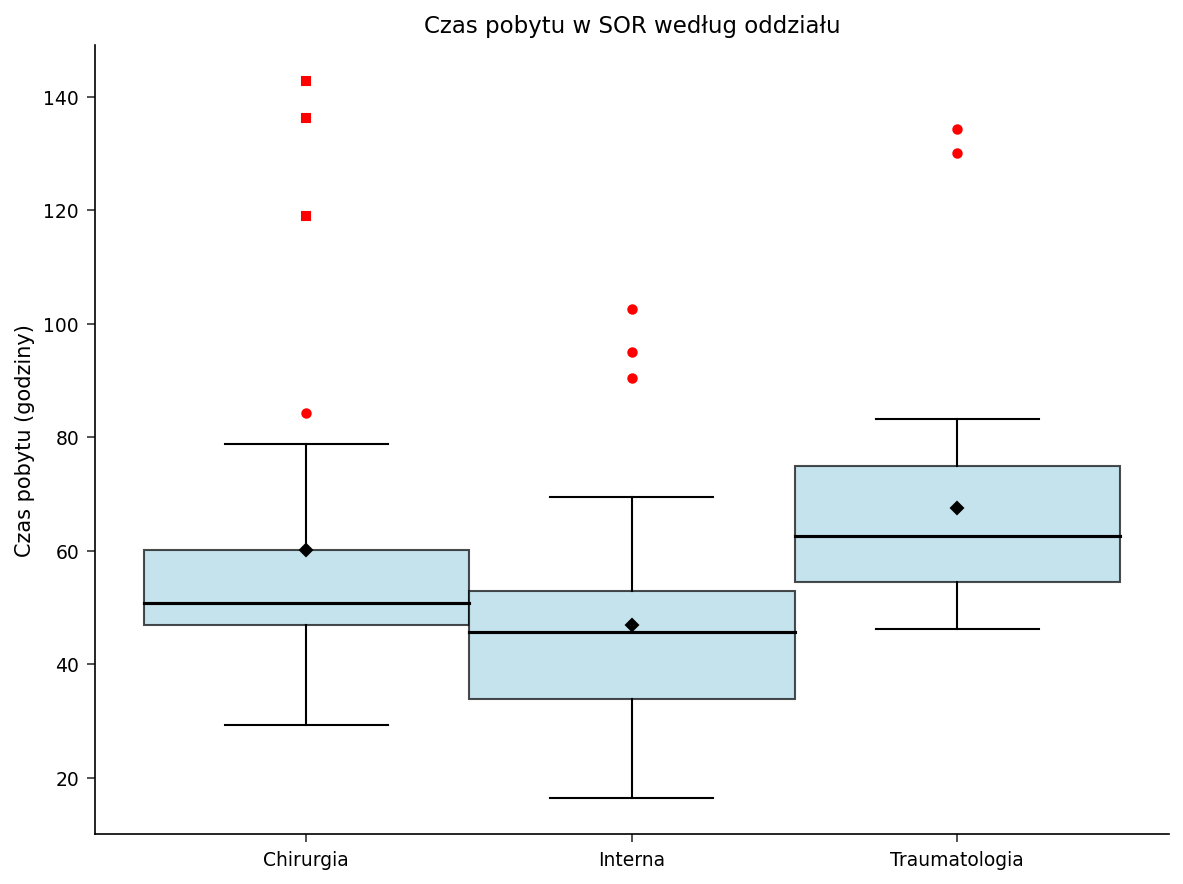

In [3]:
TYTUŁ 'Czas pobytu w SOR według oddziału';
PROCEDURA boxplot DANE=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
WYKONAJ;

## Krok 4 — Nałożenie linii trendu średniej

Aby uwidocznić gradient między służbami, dodajemy `BOXCONNECT=MEAN`. PROC BOXPLOT rysuje wówczas linię łączącą przez średnią każdego pudełka (znaczniki w kształcie rombu), zamieniając trzy oddzielne rozkłady w jeden czytelny trend. Ponieważ oddziały są uporządkowane Interna → Chirurgia → Traumatologia, rosnąca linia łącząca podsumowuje eskalację średniego czasu pobytu jednym pociągnięciem — użyteczna wskazówka dla pulpitu operacyjnego.

                       Czas pobytu w SOR według oddziału - trend średniej                       

                     Czas pobytu w SOR według oddziału - trend średniej

                                     The BOXPLOT Procedure

Schematic Plots for Czas pobytu (godziny)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgia            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Interna              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Traumatologia        30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Czas pobytu w SOR według oddziału - trend średniej.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


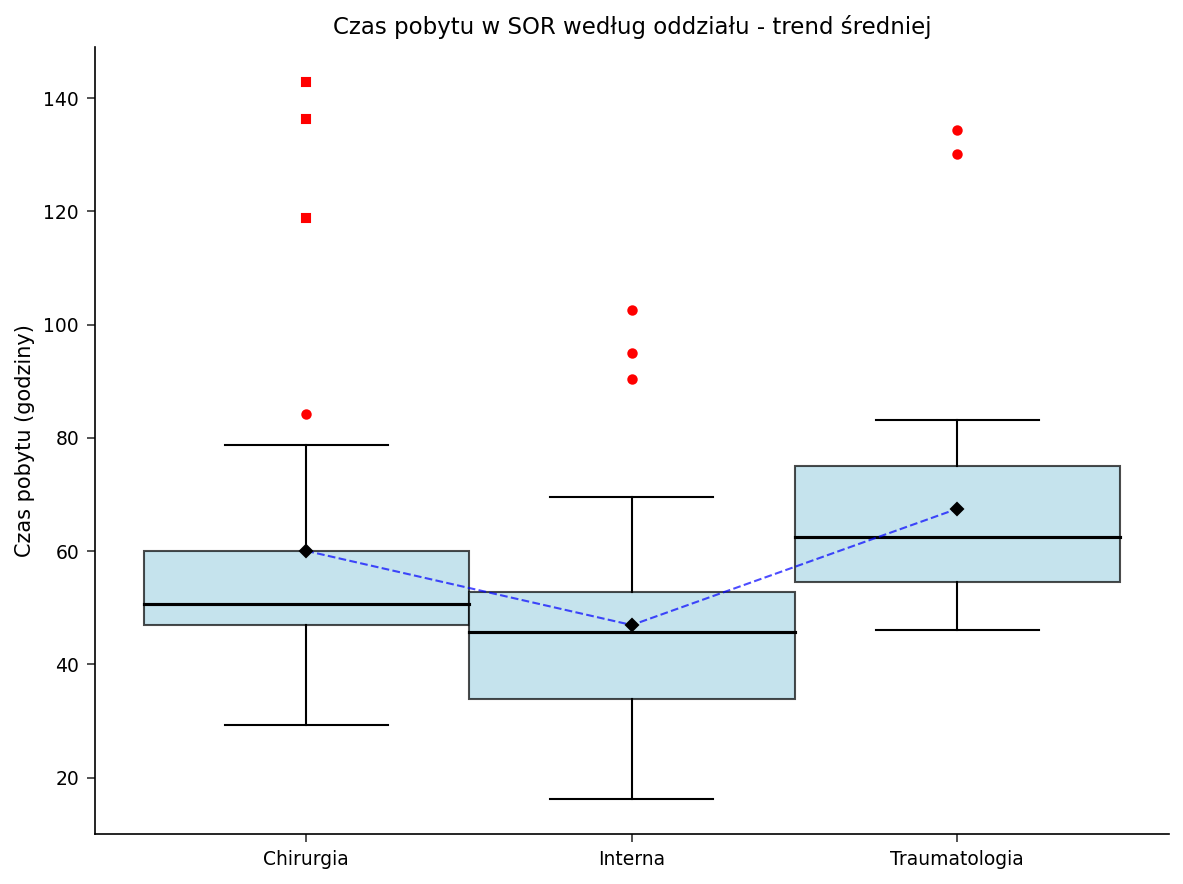

In [4]:
TYTUŁ 'Czas pobytu w SOR według oddziału - trend średniej';
PROCEDURA boxplot DANE=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
WYKONAJ;

## Krok 5 — Układ poziomy

To samo porównanie czyta się naturalnie w układzie poziomym. Dodanie `HORIZONTAL` zamienia osie, więc pudełka biegną od lewej do prawej z odpowiedzią na osi x — układ, który lepiej się skaluje, gdy nazwy służb są długie lub liczne, i który preferuje wiele pulpitów operacyjnych. Statystyki są identyczne jak w widoku pionowym; zmienia się tylko orientacja.

                       Czas pobytu w SOR według oddziału - układ poziomy                        

                      Czas pobytu w SOR według oddziału - układ poziomy

                                     The BOXPLOT Procedure

Schematic Plots for Czas pobytu (godziny)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgia            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Interna              34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Traumatologia        30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Czas pobytu w SOR według oddziału - układ poziomy.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


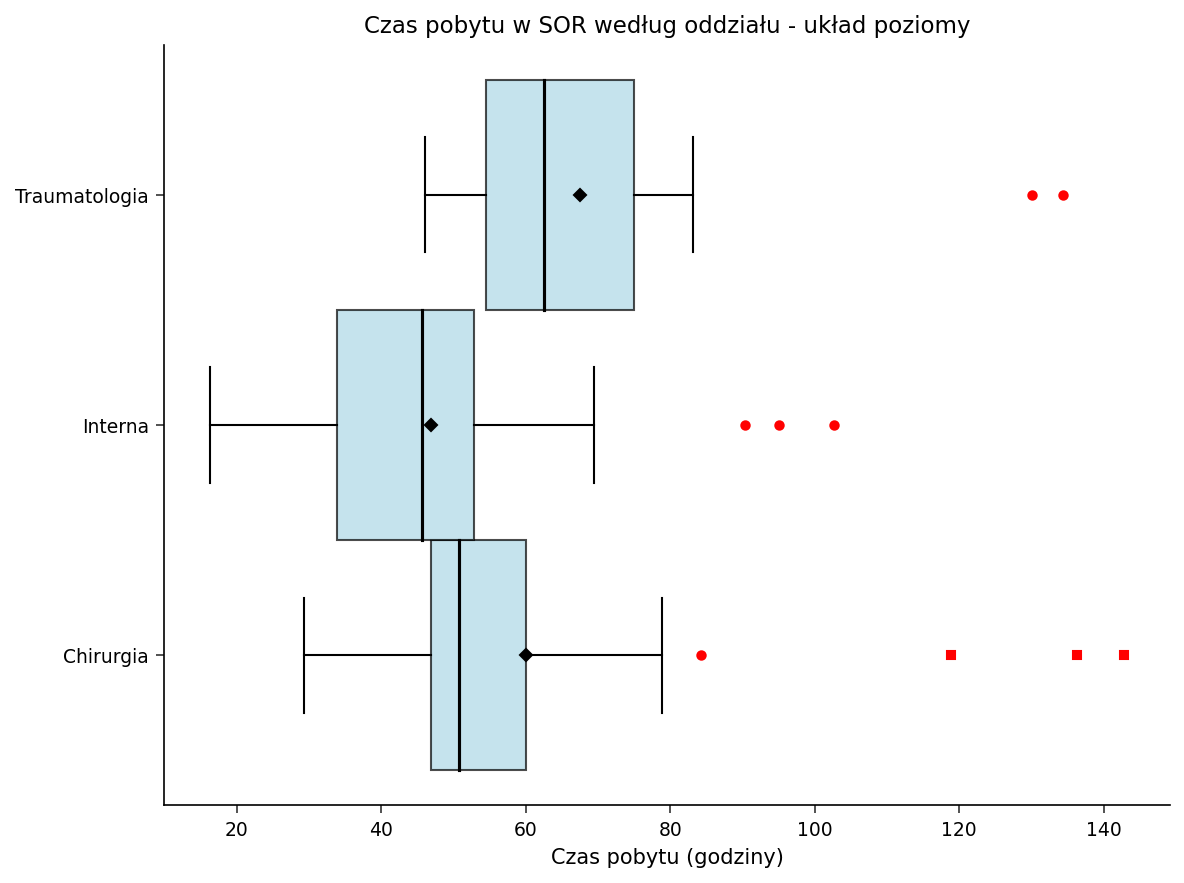

In [5]:
TYTUŁ 'Czas pobytu w SOR według oddziału - układ poziomy';
PROCEDURA boxplot DANE=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
WYKONAJ;

## Interpretacja wyników

Wykresy pudełkowe i towarzysząca tabela statystyk przekładają surowe dane LOS na obraz użyteczny operacyjnie:

- **Wyraźny gradient między służbami.** Mediana czasu pobytu rośnie monotonicznie w trzech służbach: **Interna 40.0 h → Chirurgia 50.4 h → Traumatologia 60.5 h**. Średnie opowiadają tę samą historię (41.6, 54.6, 62.8 h), a linia `BOXCONNECT=MEAN` w Kroku 4 rysuje tę eskalację jako pojedynczy rosnący trend. Pacjenci Traumatologia przebywają średnio o mniej więcej 50% dłużej niż pacjenci Interna.

- **Zmienność ma takie samo znaczenie jak mediana.** Rozstęp międzykwartylowy (wysokość pudełka) jest najszerszy dla Interna (Q1 32.8 h do Q3 51.2 h, rozrzut 18.3 godziny) i najwęższy dla Traumatologia (Q1 54.5 h do Q3 68.5 h, rozrzut 14.0 godziny). Interna jest więc nie tylko najkrótszą służbą, ale też najmniej przewidywalną — cecha, która komplikuje prognozy zarządzania łóżkami.

- **Wartości odstające sygnalizują przypadki oczekiwania na łóżko.** Schematyczne wąsy kończą się na 1.5 × IQR, więc trzy czerwone punkty powyżej górnego wąsa Chirurgia (z maksimum 84.3 h) wyróżniają się jako rzeczywiste wizyty długiego pobytu — dokładnie te przypadki oczekiwania na łóżko, które pochłaniają nieproporcjonalnie dużo godzin łóżkowych. Interna i Traumatologia nie wykazują w tej próbie żadnych punktów poza wąsami.

- **Zakres opowiada historię planowania przepustowości.** Zaobserwowane pobyty rozciągają się od 16.3–69.5 h w Interna, 29.3–84.3 h w Chirurgia oraz 46.1–83.2 h w Traumatologia. Traumatologia nigdy nie generuje krótkiego pobytu (jej minimum, 46.1 h, przekracza medianę Interna), czego zespół operacyjny oczekiwałby od najbardziej zasobochłonnej służby.

Razem te widoki dają zespołowi kierującemu oddziałem ratunkowym uzasadnioną, świadomą rozkładu podstawę do planowania obsady i przepustowości — znacznie bardziej informatywną niż samo porównanie średniego LOS między oddziałami.